In [19]:
import itertools
import re
from collections import defaultdict
from enum import Enum
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np

In [20]:
font_path = Path.cwd().parent / "fonts"
cmu_font_file = font_path / "cmunrm.otf"
font_manager.fontManager.addfont(cmu_font_file)

plt.rcParams["font.family"] = "CMU Serif"
plt.rcParams["mathtext.fontset"] = "cm"

mpl.rcParams['grid.linewidth'] = 0.5

mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['axes.edgecolor'] = 'lightgray'

mpl.rcParams["legend.frameon"] = True
mpl.rcParams["legend.facecolor"] = "white"
mpl.rcParams["legend.edgecolor"] = "gray"
mpl.rcParams["legend.framealpha"] = 1.0
mpl.rcParams["legend.fontsize"] = 10
mpl.rcParams['legend.markerscale'] = 0.8

In [61]:
LOG_DIR = Path("metrics")

class Dataset(Enum):
    DL19 = "dl19"
    DL20 = "dl20"
    TREC_COVID = "trec-covid"
    NF_CORPUS = "nfcorpus"
    SIGNAL = "signal"
    NEWS = "news"
    ROBUST04 = "robust04"
    SCIFACT = "scifact"
    TOUCHE = "touche"
    DB_PEDIA = "dbpedia-entity"

    @classmethod
    def beir_datasets(cls) -> list["Dataset"]:
        return [
            cls.TREC_COVID,
            cls.NF_CORPUS,
            cls.SIGNAL,
            cls.NEWS,
            cls.ROBUST04,
            cls.SCIFACT,
            cls.TOUCHE,
            cls.DB_PEDIA,
        ]

class AggregationStrategy(Enum):
    MEAN = "mvp_base"
    MAX = "max_aggregation"
    SMOOTH_MAX = "smooth_max_aggregation"

In [22]:
def create_log_path(
    log_dir: str | Path,
    aggregation_strategy: AggregationStrategy,
    dataset: Dataset | str,
) -> Path:
    log_dir = Path(log_dir)

    if isinstance(dataset, str):
        dataset = Dataset(dataset)
    if not isinstance(aggregation_strategy, AggregationStrategy):
        raise TypeError("Argument aggregation_strategy expected to be of type `AggregationStrategy`")

    filename = Path(aggregation_strategy.value, f"{dataset.value}.txt")
    return log_dir / filename

In [ ]:
class MetricsLog:
    def __init__(self, text: str):
        self.text = text

        self.metrics = self._metrics()

    @classmethod
    def from_file(cls, path: str | Path) -> "MetricsLog":
        path = Path(path)
        if not path.exists():
            raise FileNotFoundError(f"File does not exist: `{path}`")
        text = path.read_text(encoding="utf-8")
        return cls(text)

    @classmethod
    def from_run(
        cls,
        log_dir: str | Path,
        aggregation_strategy: AggregationStrategy,
        dataset: Dataset | str,
    ) -> "MetricsLog":
        log_path = create_log_path(log_dir, aggregation_strategy, dataset)
        return cls.from_file(log_path)
    
    def _metrics(self):
        metrics = defaultdict(dict)

        pattern = re.compile(r"([A-Za-z]+)@(\d+):\s*([0-9.]+)")

        for line in self.text.splitlines():
            match = pattern.search(line)
            if match:
                name, k, value = match.groups()
                metrics[name][int(k)] = float(value)

        return dict(metrics)
    

        

In [55]:
def average_metrics(logs: list[MetricsLog]) -> dict[str, dict[int, float]]:
    acc = defaultdict(lambda: defaultdict(list))

    for log in logs:
        for metric, ks in log.metrics.items():
            for k, value in ks.items():
                acc[metric][k].append(value)

    averaged = {
        metric: {
            k: float(np.mean(values))
            for k, values in ks.items()
            if values
        }
        for metric, ks in acc.items()
    }

    return averaged

In [56]:
log = MetricsLog.from_run(LOG_DIR, AggregationStrategy.MEAN, Dataset.DL19)
log.metrics

{'NDCG': {1: 0.8333, 2: 0.7921, 3: 0.7889, 5: 0.7728, 10: 0.743},
 'MAP': {1: 0.0255, 2: 0.0488, 3: 0.0724, 5: 0.1088, 10: 0.1685},
 'Recall': {1: 0.0255, 2: 0.0488, 3: 0.0726, 5: 0.1103, 10: 0.1756},
 'P': {1: 0.9767, 2: 0.9419, 3: 0.9457, 5: 0.907, 10: 0.8302},
 'MRR': {1: 0.9767, 2: 0.9767, 3: 0.9845, 5: 0.9845, 10: 0.9845},
 'Accuracy': {1: 0.9767, 2: 0.9767, 3: 1.0, 5: 1.0, 10: 1.0}}

In [95]:
print("BEIR Average\n")

for aggregation_strategy in AggregationStrategy:
    mean_metrics = [
        MetricsLog.from_run(LOG_DIR, aggregation_strategy, dataset)
        for dataset in Dataset.beir_datasets()
    ]
    beir_average = average_metrics(mean_metrics)["NDCG"][10]
    agg_name = aggregation_strategy.name.capitalize().replace("_", " ")
    print(f"Aggregation {agg_name}: {beir_average}")

BEIR Average

Aggregation Mean: 0.5138
Aggregation Max: 0.508125
Aggregation Smooth max: 0.5062


In [111]:
FIG_DPI = 100
# FIG_DPI = 300

def plot_dataset_and_aggregation(
    datasets,
    metric: str = "NDCG",
    metric_k: int = 10,
):
    plt.figure(figsize=(9, 4), dpi=FIG_DPI)

    n_datasets = len(datasets)
    n_aggs = len(AggregationStrategy)

    x = np.arange(n_datasets)
    width = 0.8 / n_aggs

    for i, aggregation in enumerate(AggregationStrategy):
        values = []

        for dataset in datasets:
            try:
                log = MetricsLog.from_run(
                    LOG_DIR,
                    aggregation,
                    dataset,
                )
            except FileNotFoundError:
                values.append(np.nan)
                continue

            values.append(log.metrics[metric][metric_k])

        if all(np.isnan(values)):
            continue

        plt.bar(
            x + i * width,
            values,
            width=width,
            label=aggregation.name.capitalize().replace("_", " "),
        )

    plt.xticks(
        x + width * (n_aggs - 1) / 2,
        [dataset.value for dataset in datasets],
        # rotation=30,
        ha="center",
    )

    plt.ylabel(f"{metric}@{metric_k}")
    plt.xlabel("Dataset")
    plt.ylim(0, 1.0)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.legend(title="Aggregation")
    plt.tight_layout()
    plt.show()



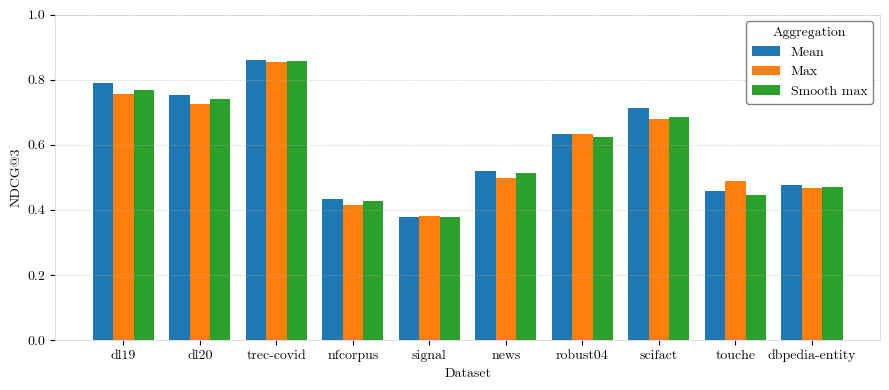

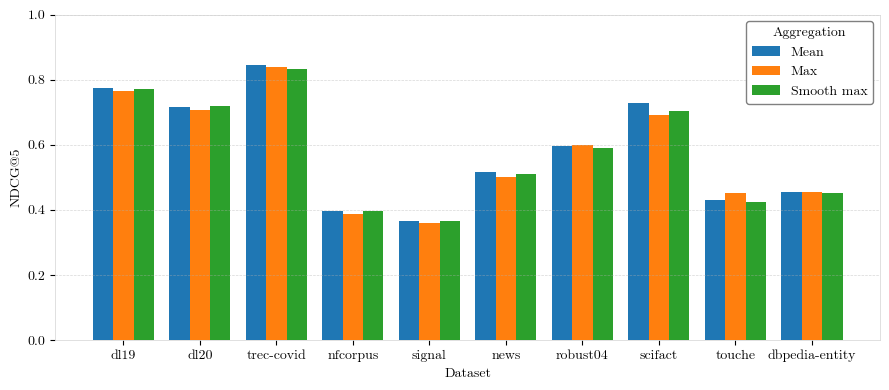

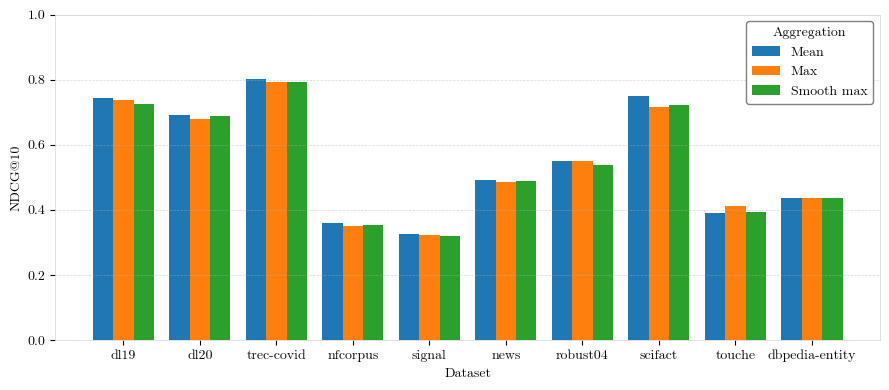

In [112]:
plot_dataset_and_aggregation(list(Dataset), "NDCG", 3)
plot_dataset_and_aggregation(list(Dataset), "NDCG", 5)
plot_dataset_and_aggregation(list(Dataset), "NDCG", 10)

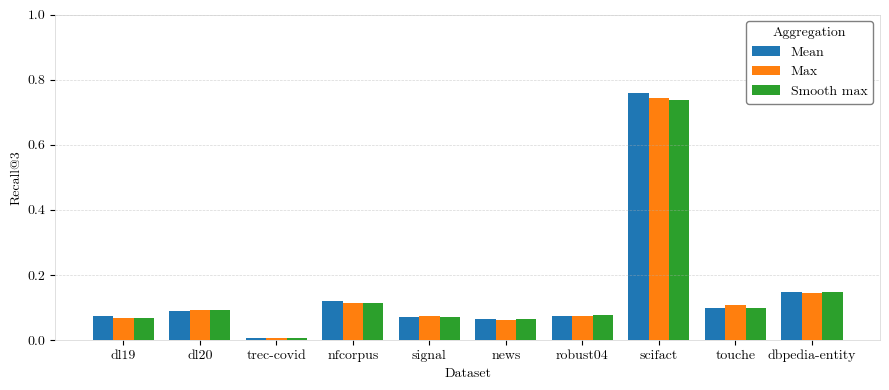

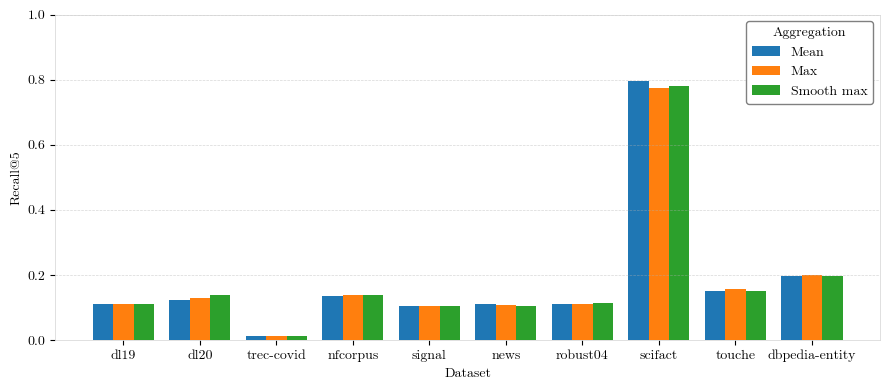

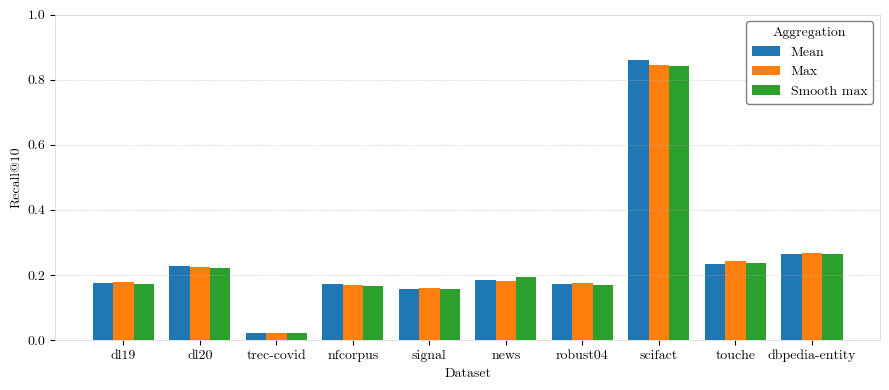

In [108]:
plot_dataset_and_aggregation(list(Dataset), "Recall", 3)
plot_dataset_and_aggregation(list(Dataset), "Recall", 5)
plot_dataset_and_aggregation(list(Dataset), "Recall", 10)